# simulated detector analysis for particle classification

This notebook analyses PPD-2 scattering images by placing virtual circular detector masks around each scattering pattern. The detector intensities are summed and converted into asymmetry factor values, so that spherical droplets and fibre-like particles can be compared.

The main workflow is:

1. Load PPD-2 scattering images or precomputed `.pkl` dataframes.
2. Simulate detector positions around the scattering centre.
3. Sum pixel intensities inside circular detector masks.
4. Calculate asymmetry factor values for each particle image.
5. Compare particle groups using histograms, intensity thresholds, and overlap/intersection measures.

Note: the original notebook uses local Windows paths. To rerun it on another machine, update the file paths or replace them with relative paths.


## Generate detector features for A1 test dust images

**Purpose:** This cell processes the A1 test dust scattering images and extracts detector-based measurements from each image.

**What the cell does:**

- Imports the main packages used for image handling, mathematics, dataframes, and plotting.
- Loads a pickle file containing previously generated random detector rotation angles.
- Loads all image files from the A1 test dust folder.
- Loops through each scattering image.
- Finds the approximate image centre using the image dimensions.
- Generates a random rotation angle, then places simulated detectors around the scattering pattern.
- Calculates detector positions for 3-detector and 6-detector layouts.
- Applies manual x/y corrections to compensate for image alignment offsets.
- Builds circular masks around each detector location.
- Extracts pixel values from each detector mask.
- Sums detector intensities and calculates asymmetry factor values.
- Stores the results in dataframe rows for later comparison.

**Scientific meaning:** A1 test dust is treated as one of the non-spherical/non-droplet reference samples. The summed detector signals estimate how much light falls into each virtual detector, while the asymmetry factor captures how uneven the scattering pattern is.

**Key output:** A dataframe containing detector sums, image identifiers, detector rotation information, and asymmetry factor values for A1 test dust.

**Review note:** This cell is long and repeats some detector-position logic. A future cleaner version could turn the detector coordinate calculation, circular masking, and asymmetry factor calculation into separate reusable functions.


In [21]:
from os import listdir
from os.path import isfile, join
import numpy as np
import cv2
import math
import pandas as pd
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plot
import random

wol_lt_2 = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\new file\random_lt0.2_200.pkl')
#print (wol_lt_2[index])

a=wol_lt_2['random degree'] 
A = a.values.tolist()

B= wol_lt_2.index.tolist() 
#print (B)

final = pd.DataFrame()
final2 = pd.DataFrame()
mypath=r'C:\Users\altin\Documents\Aerosol\proposal\TBS\Altin\A1 Test dust'

onlyfiles = [ f for f in listdir(mypath) if isfile(join(mypath,f)) ]
images = np.empty(len(onlyfiles), dtype=object)
for n in range(0, len(onlyfiles)):
      images[n] = cv2.imread( join(mypath,onlyfiles[n]) )
import matplotlib.pyplot as plt
#print(onlyfiles)
np.random.seed (0)
randomlist = []
for n in range (len(images)):
    #plt.subplot(3,2,n+1)
    #plt.subplot(5,2, n+1)
    #plt.imshow(images[n],interpolation='none',cmap='gray')
    #plt.savefig(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\figure.jpg')
    
    #print (len(images))
    
    #print (type(images[n]))     # Check that img is a variable of type ndarray
    #print (images[n].dtype)
    #print ("Loaded array has shape", images[n].shape)
    h, w, c = images[n].shape
    #print('width:  ', w)
    #print('height: ', h)
    #print('channel:', c)

    cy = w/2 # cy
    cx = h/2 # cx

    #print (cx,cy)
    
    

    #print (A)
    #for i in range(len(images)):
        #random.seed (0)
    p = np.random.randint(0, 60)
    randomlist.append(p)
    #print(randomlist)
    

   
    for r in (200, 700):
        Y1 = cy
        X1 = cx - math.sqrt(r**2 - ((Y1 - cy)**2))

        #print (A[1])

        X120 = (np.cos(math.radians(120))*(X1 - cx)) - (np.sin(math.radians(120))*(Y1 - cy)) + cx
        Y120 = (np.sin(math.radians(120))*(X1 - cx)) + (np.cos(math.radians(120))*(Y1 - cy)) + cy
        #print (X120, Y120)

        X240 = (np.cos(math.radians(240))*(X1 - cx)) - (np.sin(math.radians(240))*(Y1 - cy)) + cx
        Y240 = (np.sin(math.radians(240))*(X1 - cx)) + (np.cos(math.radians(240))*(Y1 - cy)) + cy
        #print (X240, Y240)

        #-------------------------------------
        X45 = (np.cos(math.radians(randomlist[n]))*(X1 - cx)) - (np.sin(math.radians(randomlist[n]))*(Y1 - cy)) + cx
        Y45 = (np.sin(math.radians(randomlist[n]))*(X1 - cx)) + (np.cos(math.radians(randomlist[n]))*(Y1 - cy)) + cy
        #print (X45, Y45)

        X60 = (np.cos(math.radians(60))*(X45 - cx)) - (np.sin(math.radians(60))*(Y45 - cy)) + cx
        Y60 = (np.sin(math.radians(60))*(X45 - cx)) + (np.cos(math.radians(60))*(Y45 - cy)) + cy
        #print (X165, Y165)

        X120 = (np.cos(math.radians(120))*(X45 - cx)) - (np.sin(math.radians(120))*(Y45 - cy)) + cx
        Y120 = (np.sin(math.radians(120))*(X45 - cx)) + (np.cos(math.radians(120))*(Y45 - cy)) + cy
        #print (X285, Y285)

        X180 = (np.cos(math.radians(180))*(X45 - cx)) - (np.sin(math.radians(180))*(Y45 - cy)) + cx
        Y180 = (np.sin(math.radians(180))*(X45 - cx)) + (np.cos(math.radians(180))*(Y45 - cy)) + cy
        #print (X165, Y165)

        X240 = (np.cos(math.radians(240))*(X45 - cx)) - (np.sin(math.radians(240))*(Y45 - cy)) + cx
        Y240 = (np.sin(math.radians(240))*(X45 - cx)) + (np.cos(math.radians(240))*(Y45 - cy)) + cy
        #print (X285, Y285)
        
        X300 = (np.cos(math.radians(300))*(X45 - cx)) - (np.sin(math.radians(300))*(Y45 - cy)) + cx
        Y300 = (np.sin(math.radians(300))*(X45 - cx)) + (np.cos(math.radians(300))*(Y45 - cy)) + cy
        #print (X285, Y285)
        #-------------------------------------
        X90 = (np.cos(math.radians(90))*(X1 - cx)) - (np.sin(math.radians(90))*(Y1 - cy)) + cx
        Y90 = (np.sin(math.radians(90))*(X1 - cx)) + (np.cos(math.radians(90))*(Y1 - cy)) + cy

        #print (X90, Y90)

        X210 = (np.cos(math.radians(120))*(X90 - cx)) - (np.sin(math.radians(120))*(Y90 - cy)) + cx
        Y210 = (np.sin(math.radians(120))*(X90 - cx)) + (np.cos(math.radians(120))*(Y90 - cy)) + cy
        #print (X210, Y210)

        X330 = (np.cos(math.radians(240))*(X90 - cx)) - (np.sin(math.radians(240))*(Y90 - cy)) + cx
        Y330 = (np.sin(math.radians(240))*(X90 - cx)) + (np.cos(math.radians(240))*(Y90 - cy)) + cy
        #print (X330, Y330)

        correction_x = 3
        correction_y = 10
        
        cx1 = int(X1) + correction_x
        cy1 = int(Y1) + correction_y
        cx120 = int(X120) + correction_x
        cy120 = int(Y120) + correction_y
        cx240 = int(X240) + correction_x
        cy240 = int(Y240) + correction_y
        #print (cx1, cy1) 
        #print (cx120, cy120) 
        #print (cx240, cy240)

        grid_0 = images [n] [cx1:(cx1+50), cy1:(cy1+50)] #=255
        grid_120 = images [n] [cx120:(cx120+50), cy120:(cy120+50)] #=255
        grid_240 = images [n] [cx240:(cx240+50), cy240:(cy240+50)] #=255
        
        #circle matrix - # if you want to only use the square matrix
        cirx,ciry = np.ogrid[0:h, 0:w]

        c0 = (cirx-cx1)**2 + (ciry-cy1)**2 <= 75**2
        c120 = (cirx-cx120)**2 + (ciry-cy120)**2 <= 75**2
        c240 = (cirx-cx240)**2 + (ciry-cy240)**2 <= 75**2

        circle_0 = images [n][c0] #=[255]
        circle_120 = images [n][c120] #=[255]
        circle_240 = images [n][c240] #=[255]
        
        


        #square matrix - 45, 165, 285 degrees
        cx45 = int(X45) + correction_x
        cy45 = int(Y45) + correction_y
        cx60 = int(X60) + correction_x
        cy60 = int(Y60) + correction_y
        cx120 = int(X120) + correction_x
        cy120 = int(Y120) + correction_y
        cx180 = int(X180) + correction_x
        cy180 = int(Y180) + correction_y
        cx240 = int(X240) + correction_x
        cy240 = int(Y240) + correction_y
        cx300 = int(X300) + correction_x
        cy300 = int(Y300) + correction_y
        #print (cx45, cy45) 
        #print (cx165, cy165) 
        #print (cx285, cy285)

        grid_45 = images [n] [cx45:(cx45+50), cy45:(cy45+50)] #=255
        grid_165 = images [n] [cx60:(cx60+50), cy60:(cy60+50)] #=255
        grid_285 = images [n] [cx120:(cx120+50), cy120:(cy120+50)] #=255
        
        #circle matrix - # if you want to only use the square matrix
        c45 = (cirx-cx45)**2 + (ciry-cy45)**2 <= 50**2
        c60 = (cirx-cx60)**2 + (ciry-cy60)**2 <= 50**2
        c120 = (cirx-cx120)**2 + (ciry-cy120)**2 <=50**2
        c180 = (cirx-cx180)**2 + (ciry-cy180)**2 <= 50**2
        c240 = (cirx-cx240)**2 + (ciry-cy240)**2 <=50**2
        c300 = (cirx-cx300)**2 + (ciry-cy300)**2 <= 50**2
        

        circle_45 = images [n][c45] #=[255] #- images [n][c45])
        circle_60 = images [n][c60] #=[255] #- images [n][c165])
        circle_120 = images [n][c120] #=[255] #- images [n][c285])
        circle_180 = images [n][c180] #=[255] #- images [n][c45])
        circle_240 = images [n][c240] #=[255] #- images [n][c165])
        circle_300 = images [n][c300] #=[255] #- images [n][c285])
        
        #C = B[n]
        #print (C)
        
        #result=cv2.imwrite(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\Altin\wollastonite5\wol1_{0}.jpg'.format(n), images[n])
        #if result==True:
            #print("File saved successfully")
        #else:
            #print("Error in saving file")

        cx90 = int(X90) + correction_x
        cy90 = int(Y90) + correction_y
        cx210 = int(X210) + correction_x
        cy210 = int(Y210) + correction_y
        cx330 = int(X330) + correction_x
        cy330 = int(Y330) + correction_y
        #print (cx90, cy90) 
        #print (cx210, cy210) 
        #print (cx330, cy330)

        grid_90 = images [n] [cx90:(cx90+50), cy90:(cy90+50)] #=255
        grid_210 = images [n] [cx210:(cx210+50), cy210:(cy210+50)] #=255
        grid_330 = images [n] [cx330:(cx330+50), cy330:(cy330+50)] #=255
        
        #circle matrix - # if you want to only use the square matrix
        c90 = (cirx-cx90)**2 + (ciry-cy90)**2 <= 75**2
        c210 = (cirx-cx210)**2 + (ciry-cy210)**2 <= 75**2
        c330 = (cirx-cx330)**2 + (ciry-cy330)**2 <= 75**2

        circle_90 = images [n][c90] #=[255]
        circle_210 = images [n][c210] #=[255]
        circle_330 = images [n][c330] #=[255]
        
        #measure of size
        cxcs = int(cx) + correction_x
        cycb = int(cy) + correction_y
        
        central_c = (cirx-cxcs)**2 + (ciry-cycb)**2 <= 65**2
        central_cbig = (cirx-cxcs)**2 + (ciry-cycb)**2 <= 293**2
    
        circle_c = images[n][central_c] =[0]
        circle_cbig = images[n][central_cbig] #=[0]

        #plt.imshow(images[n],interpolation='none',cmap='gray')

        #if r == 150:
            #print ("r=150")
        #else:
            #print ("r=250")
        type(grid_0)
        type(grid_120)
        type(grid_240)
        if r== 200:

            #print ("A1 0:",grid_0.sum(), grid_120.sum(), grid_240.sum())
            #print ("A2 45:",grid_45.sum(), grid_165.sum(), grid_285.sum())
            #print ("A3 90:",grid_90.sum(), grid_210.sum(), grid_330.sum())
            a = {'filename': onlyfiles[n],
                 'image depth': images[n].dtype,
                 'radius': 100,
                 '0': grid_0.sum(), 
                 '120': grid_120.sum(), 
                 '240': grid_240.sum(), 
                 '45': grid_45.sum(), 
                 '165':grid_165.sum(), 
                 '285': grid_285.sum(),
                 '90': grid_90.sum(), 
                 '210': grid_210.sum(), 
                 '330': grid_330.sum(), 
                }
            
            cir_a = {'filename': onlyfiles[n],
                 'image depth': images[n].dtype,
                 'radius': 200,
                 'random degree': randomlist[n],
                 #'0': circle_0.sum(), 
                 #'120': circle_120.sum(), 
                 #'240': circle_240.sum(), 
                 #'45': circle_45.sum(), 
                 #'165': circle_60.sum(), 
                 #'285': circle_120.sum(),
                 #'90': circle_90.sum(), 
                 #'210': circle_210.sum(), 
                 #'330': circle_330.sum(), 
                }
            

            
            #result=cv2.imwrite(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\Altin\cut offs\wol_alt_gt_0.8\wol_{0}.jpg'.format(n), images[n])
            #if result==True:
                #print("File saved successfully")
            #else:
                #print("Error in saving file")
        else:
            #print ("A1 0:",grid_0.sum(), grid_120.sum(), grid_240.sum())
            #print ("A2 45:",grid_45.sum(), grid_165.sum(), grid_285.sum())
            #print ("A3 90:",grid_90.sum(), grid_210.sum(), grid_330.sum())
            b = {'filename': onlyfiles[n],
                 'image depth': images[n].dtype,
                 'radius': 250,
                 '0': grid_0.sum(), 
                 '120': grid_120.sum(), 
                 '240': grid_240.sum(), 
                 '45': grid_45.sum(), 
                 '165':grid_165.sum(), 
                 '285': grid_285.sum(),
                 '90': grid_90.sum(), 
                 '210': grid_210.sum(), 
                 '330': grid_330.sum(), 
                }
            
            cir_b = {'filename': onlyfiles[n],
                 'image depth': images[n].dtype,
                 'radius': 250,
                 '0': circle_0.sum(), 
                 #'120': circle_120.sum(), 
                 #'240': circle_240.sum(), 
                 #'45': circle_45.sum(), 
                 #'165': circle_165.sum(), 
                 #'285': circle_285.sum(),
                 #'90': circle_90.sum(), 
                 #'210': circle_210.sum(), 
                 #'330': circle_330.sum(), 
                }


        if r == 200:
            total_0_120_240 = grid_0.sum() + grid_120.sum() + grid_240.sum()
            total_45_165_285 = grid_45.sum() + grid_165.sum() + grid_285.sum()
            total_90_210_330 = grid_90.sum() + grid_210.sum() + grid_330.sum()
            #print ("total_0_120_240", total_0_120_240)
            #print ("total_45_165_285", total_45_165_285)
            #print ("total_90_210_330", total_90_210_330)
            mean_0_120_240 = total_0_120_240/3
            mean_45_165_285 = total_45_165_285/3
            mean_90_210_330 = total_90_210_330/3

            AF_0_120_240 = ((math.sqrt(((mean_0_120_240 - grid_0.sum()) ** 2) + ((mean_0_120_240 - grid_120.sum()) ** 2) + ((mean_0_120_240 - grid_240.sum()) ** 2)))/mean_0_120_240) * (0.40875
)
            AF_45_165_285 = ((math.sqrt(((mean_45_165_285 - grid_45.sum()) ** 2) + ((mean_45_165_285 - grid_165.sum()) ** 2) + ((mean_45_165_285 - grid_285.sum()) ** 2)))/mean_45_165_285) * (0.40875
)
            AF_90_210_330 = ((math.sqrt(((mean_90_210_330 - grid_90.sum()) ** 2) + ((mean_90_210_330 - grid_210.sum()) ** 2) + ((mean_90_210_330 - grid_330.sum()) ** 2)))/mean_90_210_330) * (0.40875
)
            #print ("AF_0_120_240", AF_0_120_240,"AF_45_165_285", AF_45_165_285,"AF_90_210_330", AF_90_210_330)

            
            #c_total_0_120_240 = circle_0.sum() + circle_120.sum() + circle_240.sum()
            c_total_45_165_285 = circle_45.sum() + circle_60.sum() + circle_120.sum() + circle_180.sum() + circle_240.sum() + circle_300.sum()
            #c_total_90_210_330 = circle_90.sum() + circle_210.sum() + circle_330.sum()
            #print ("total_0_120_240", total_0_120_240)
            #print ("total_45_165_285", total_45_165_285)
            #print ("total_90_210_330", total_90_210_330)
            #c_mean_0_120_240 = c_total_0_120_240/3
            c_mean_45_165_285 = c_total_45_165_285/6
            #c_mean_90_210_330 = c_total_90_210_330/3
            
            scale = 1/((math.sqrt(((c_mean_45_165_285 - circle_45.sum()) ** 2) + ((c_mean_45_165_285 - circle_60.sum()) ** 2) + ((c_mean_45_165_285 - circle_120.sum()) ** 2) + ((c_mean_45_165_285 - circle_180.sum()) ** 2) + ((c_mean_45_165_285 - circle_240.sum()) ** 2) +((c_mean_45_165_285 - circle_300.sum()) ** 2)))/c_mean_45_165_285)
            #print (scale)
            
            
            #AFc_0_120_240 = ((math.sqrt(((c_mean_0_120_240 - circle_0.sum()) ** 2) + ((c_mean_0_120_240 - circle_120.sum()) ** 2) + ((c_mean_0_120_240 - circle_240.sum()) ** 2)))/c_mean_0_120_240) * (0.3276827694295457
#)
            AFc_45_165_285 = ((math.sqrt(((c_mean_45_165_285 - circle_45.sum()) ** 2) + ((c_mean_45_165_285 - circle_60.sum()) ** 2) + (
                (c_mean_45_165_285 - circle_120.sum()) ** 2) + ((c_mean_45_165_285 - circle_180.sum()) ** 2) + ((c_mean_45_165_285 - circle_240.sum()) ** 2) +((c_mean_45_165_285 - circle_300.sum()) ** 2)))/c_mean_45_165_285) * (0.1832972980
)
            #AFc_90_210_330 = ((math.sqrt(((c_mean_90_210_330 - circle_90.sum()) ** 2) + ((c_mean_90_210_330 - circle_210.sum()) ** 2) + ((c_mean_90_210_330 - circle_330.sum()) ** 2)))/c_mean_90_210_330) * (0.3276827694295457
#)
            #print ("AF_0_120_240", AF_0_120_240,"AF_45_165_285", AF_45_165_285,"AF_90_210_330", AF_90_210_330)
            
            #scale = 1/(math.sqrt((AAbar - AA1.sum()) ** 2 + (AAbar - AA2.sum()) ** 2 + (AAbar - AAA3.sum()) ** 2) / AAbar)
            #print ("scale", scale)
            
            
            c = {'filename': onlyfiles[n],
                 'image depth': images[n].dtype,
                 'radius': 150,
                 'sum of 0,120,240': total_0_120_240, 
                 'sum of 45,165,285': total_45_165_285, 
                 'sum of 90,210,330': total_90_210_330, 
                 'AF_0_120_240': AF_0_120_240, 
                 'AF_45_165_285': AF_45_165_285, 
                 'AF_90_210_330': AF_90_210_330, 
                }
            
            cir_c = {'filename': onlyfiles[n],
                     'image depth': images[n].dtype,
                     'radius': 200,
                     'random degree': randomlist[n],
                     #'sum of 0,120,240': c_total_0_120_240, 
                     'sum of 45,165,285': c_total_45_165_285, 
                     #'sum of 90,210,330': c_total_90_210_330, 
                     #'AF_0_120_240': AFc_0_120_240, 
                     'AF_45_165_285': AFc_45_165_285, 
                     #'AF_90_210_330': AFc_90_210_330, 
                     }
            
            cir_cc = {'filename': onlyfiles[n],
                     'image depth': images[n].dtype,
                     'radius': 200,
                     'random degree': randomlist[n],
                     'sum_image': circle_cbig.sum(),
                     'sum_random': total_45_165_285,
                    }

        else:
            total_0_120_240 = grid_0.sum() + grid_120.sum() + grid_240.sum()
            total_45_165_285 = grid_45.sum() + grid_165.sum() + grid_285.sum()
            total_90_210_330 = grid_90.sum() + grid_210.sum() + grid_330.sum()
            #print ("total_0_120_240", total_0_120_240)
            #print ("total_45_165_285", total_45_165_285)
            #print ("total_90_210_330", total_90_210_330)
            mean_0_120_240 = total_0_120_240/3
            mean_45_165_285 = total_45_165_285/3
            mean_90_210_330 = total_90_210_330/3

            AF_0_120_240 = ((math.sqrt(((mean_0_120_240 - grid_0.sum()) ** 2) + ((mean_0_120_240 - grid_120.sum()) ** 2) + ((mean_0_120_240 - grid_240.sum()) ** 2)))/mean_0_120_240) * (0.40875
)
            AF_45_165_285 = ((math.sqrt(((mean_45_165_285 - grid_45.sum()) ** 2) + ((mean_45_165_285 - grid_165.sum()) ** 2) + ((mean_45_165_285 - grid_285.sum()) ** 2)))/mean_45_165_285) * (0.40875
)
            AF_90_210_330 = ((math.sqrt(((mean_90_210_330 - grid_90.sum()) ** 2) + ((mean_90_210_330 - grid_210.sum()) ** 2) + ((mean_90_210_330 - grid_330.sum()) ** 2)))/mean_90_210_330) * (0.40875
)
            #print ("AF_0_120_240", AF_0_120_240,"AF_45_165_285", AF_45_165_285,"AF_90_210_330", AF_90_210_330)
            
            
            c_total_0_120_240 = circle_0.sum() + circle_120.sum() + circle_240.sum()
            c_total_45_165_285 = circle_45.sum() + circle_120.sum() + circle_60.sum()
            c_total_90_210_330 = circle_90.sum() + circle_210.sum() + circle_330.sum()
            #print ("total_0_120_240", total_0_120_240)
            #print ("total_45_165_285", total_45_165_285)
            #print ("total_90_210_330", total_90_210_330)
            c_mean_0_120_240 = c_total_0_120_240/3
            c_mean_45_165_285 = c_total_45_165_285/3
            c_mean_90_210_330 = c_total_90_210_330/3
            
            AFc_0_120_240 = ((math.sqrt(((c_mean_0_120_240 - circle_0.sum()) ** 2) + ((c_mean_0_120_240 - circle_120.sum()) ** 2) + ((c_mean_0_120_240 - circle_240.sum()) ** 2)))/c_mean_0_120_240) * (0.40875
)
            AFc_45_165_285 = ((math.sqrt(((c_mean_45_165_285 - circle_45.sum()) ** 2) + ((c_mean_45_165_285 - circle_60.sum()) ** 2) + ((c_mean_45_165_285 - circle_120.sum()) ** 2)))/c_mean_45_165_285) * (0.40875
)
            AFc_90_210_330 = ((math.sqrt(((c_mean_90_210_330 - circle_90.sum()) ** 2) + ((c_mean_90_210_330 - circle_210.sum()) ** 2) + ((c_mean_90_210_330 - circle_330.sum()) ** 2)))/c_mean_90_210_330) * (0.40875
)
            #print ("AF_0_120_240", AF_0_120_240,"AF_45_165_285", AF_45_165_285,"AF_90_210_330", AF_90_210_330)
            
            
            d = {'filename': onlyfiles[n],
                 'image depth': images[n].dtype,
                 'radius': 250,
                 'sum of 0,120,240': total_0_120_240, 
                 'sum of 45,165,285': total_45_165_285, 
                 'sum of 90,210,330': total_90_210_330, 
                 'AF_0_120_240': AF_0_120_240, 
                 'AF_45_165_285': AF_45_165_285, 
                 'AF_90_210_330': AF_90_210_330, 
                }
            
            cir_d = {'filename': onlyfiles[n],
                 'image depth': images[n].dtype,
                 'radius': 250,
                 'random degree': p,
                 'sum of 0,120,240': c_total_0_120_240, 
                 'sum of 45,165,285': c_total_45_165_285, 
                 'sum of 90,210,330': c_total_90_210_330, 
                 'AF_0_120_240': AFc_0_120_240, 
                 'AF_45_165_285': AFc_45_165_285, 
                 'AF_90_210_330': AFc_90_210_330, 
                    }

            cir_e = {'AF_0_120_240': AFc_0_120_240,
                    }

    df = pd.DataFrame([cir_c])
    #df2 = pd.DataFrame([cir_d])
    #df1 = df.transpose()
    final = final.append(df)
    #final2 = final2.append(df2)
    #print (final)
            
    #final.to_csv (r'C:\Users\altin\Documents\Aerosol\proposal\TBS\Altin\water200.csv', header=True)
    
    #df['AF_0_120_240']
    
    final.to_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\6 detectors\a1_r50.pkl')
    #final2.to_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\corrected dataframes\A1_Test_dust_200.pkl')

<ipython-input-21-e8313fb4cb98>:417: RuntimeWarning: invalid value encountered in double_scalars
  AFc_0_120_240 = ((math.sqrt(((c_mean_0_120_240 - circle_0.sum()) ** 2) + ((c_mean_0_120_240 - circle_120.sum()) ** 2) + ((c_mean_0_120_240 - circle_240.sum()) ** 2)))/c_mean_0_120_240) * (0.40875
<ipython-input-21-e8313fb4cb98>:419: RuntimeWarning: invalid value encountered in double_scalars
  AFc_45_165_285 = ((math.sqrt(((c_mean_45_165_285 - circle_45.sum()) ** 2) + ((c_mean_45_165_285 - circle_60.sum()) ** 2) + ((c_mean_45_165_285 - circle_120.sum()) ** 2)))/c_mean_45_165_285) * (0.40875
<ipython-input-21-e8313fb4cb98>:421: RuntimeWarning: invalid value encountered in double_scalars
  AFc_90_210_330 = ((math.sqrt(((c_mean_90_210_330 - circle_90.sum()) ** 2) + ((c_mean_90_210_330 - circle_210.sum()) ** 2) + ((c_mean_90_210_330 - circle_330.sum()) ** 2)))/c_mean_90_210_330) * (0.40875


## Compare raw detector intensity and asymmetry factor distributions

**Purpose:** This cell compares four particle types using histograms from the precomputed 6-detector dataframes.

**What the cell does:**

- Loads pickle files for A1 test dust, gypsum, water, and wollastonite.
- Adds a `species` label to each dataframe.
- Plots histograms of `sum of 45,165,285`, which represents the summed intensity from one detector triplet.
- Plots histograms of `AF_45_165_285`, the asymmetry factor calculated from that detector triplet.

**Scientific meaning:** The intensity histogram gives a size/signal proxy, while the AF histogram shows how symmetrical or asymmetrical each particle type is. Water droplets are expected to cluster at low AF because their scattering patterns are more circular. Fibre-like particles are expected to shift towards higher AF.

**Key output:** Two comparison histograms: one for detector intensity and one for asymmetry factor.

**Review note:** The plotting code uses `plt.subplots`, but the cell imports `matplotlib.pyplot as plot`. It will work only if `plt` was already imported in an earlier cell. For portability, add `import matplotlib.pyplot as plt` inside this cell.


<ipython-input-14-90d55add70e3>:28: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([A1_Test_dust[['sum of 45,165,285']],
<ipython-input-14-90d55add70e3>:44: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([A1_Test_dust[['AF_45_165_285']],


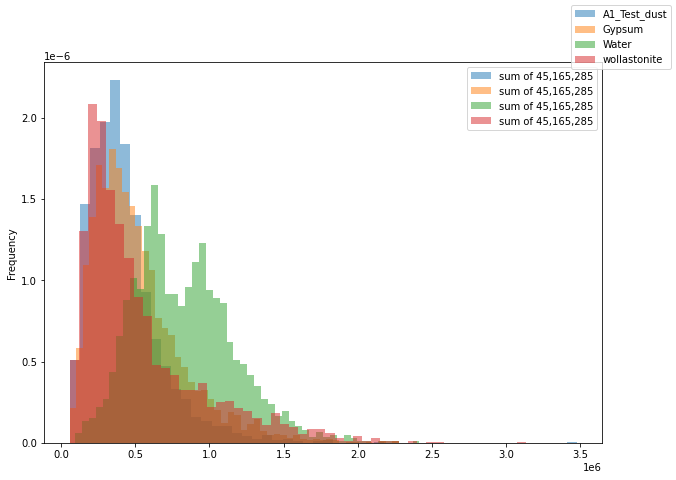

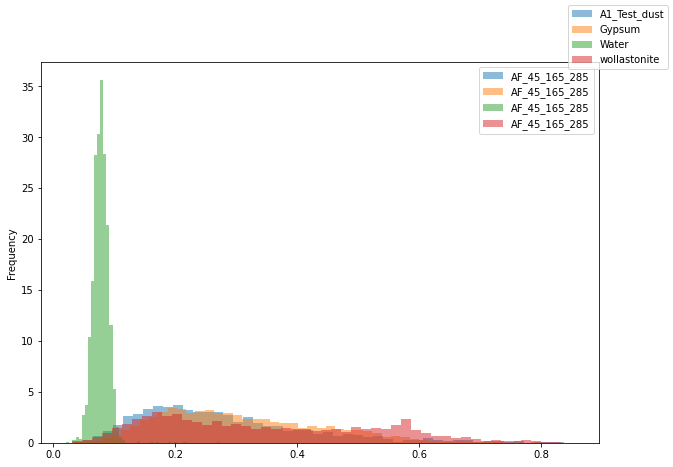

In [14]:
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plot
import seaborn as sns

A1_Test_dust = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\6 detectors\a1_r25.pkl')
Gypsum = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\6 detectors\gyp_r25.pkl')
Water = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\6 detectors\wat_r25.pkl')
wollastonite = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\6 detectors\wol_r25.pkl')




A1_Test_dust['species'] = 'A1_Test_dust'
Gypsum['species'] = 'Gypsum'
Water['species'] ='Water'
wollastonite['species'] ='wollastonite'

labels = ["A1_Test_dust", "Gypsum", "Water", "wollastonite"]

fig, ax = plt.subplots(figsize =(10, 7))

A1_Test_dust[['sum of 45,165,285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
Gypsum[['sum of 45,165,285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
Water[['sum of 45,165,285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
wollastonite[['sum of 45,165,285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)


fig.legend([A1_Test_dust[['sum of 45,165,285']],
            Gypsum[['sum of 45,165,285']],
            Water[['sum of 45,165,285']],
            wollastonite[['sum of 45,165,285']],
            ], labels=labels,loc="upper right")

labels = ["A1_Test_dust", "Gypsum", "Water", "wollastonite"]

fig, ax = plt.subplots(figsize =(10, 7))

A1_Test_dust[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
Gypsum[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
Water[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
wollastonite[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)


fig.legend([A1_Test_dust[['AF_45_165_285']],
            Gypsum[['AF_45_165_285']],
            Water[['AF_45_165_285']],
            wollastonite[['AF_45_165_285']],
            ], labels=labels,loc="upper right")

## Apply an asymmetry factor cut-off and compare high-AF particles

**Purpose:** This cell tests a classification threshold by selecting particles with asymmetry factor values above 0.5.

**What the cell does:**

- Reloads the four particle dataframes.
- Adds species labels.
- Sets `amount = 0.5` as the asymmetry factor threshold.
- Filters each particle dataframe to keep only particles where `AF_45_165_285 > 0.5`.
- Prints the original particle counts and the number remaining after the cut-off.
- Plots the full AF distributions.
- Plots the AF distributions after the >0.5 filter.

**Scientific meaning:** This tests whether a high-AF region can enrich for fibres. Since fibres produce more uneven scattering, a high-AF cut-off should retain more wollastonite and gypsum-like fibre scatters than water droplets.

**Key output:** Particle counts before and after filtering, plus histograms showing the high-AF subset.

**Review note:** The threshold is set manually. In the report, thresholds around >0.5 or >0.6 were used to define fibre-like regions, depending on detector number, detector radius, and size threshold.


2984 4422 2229 2332
252 417 0 578


<ipython-input-15-5b5a3cab48da>:37: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([A1_Test_dust[['AF_45_165_285']],
C:\Users\altin\anaconda3\lib\site-packages\numpy\lib\histograms.py:908: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
<ipython-input-15-5b5a3cab48da>:51: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([A1_Test_dust[['AF_45_165_285']],


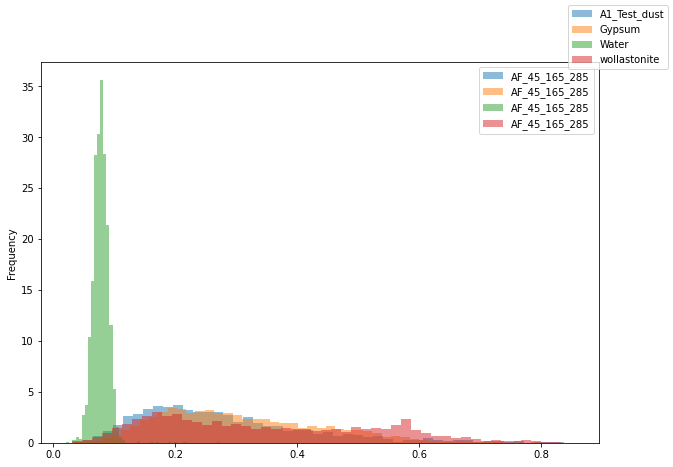

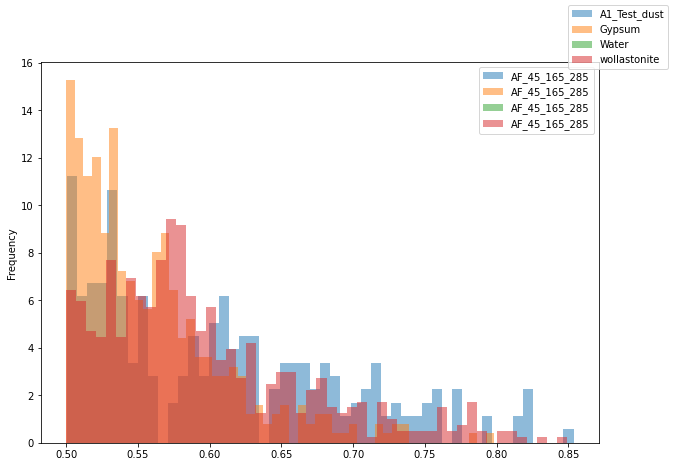

In [15]:
A1_Test_dust = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\6 detectors\a1_r25.pkl')
Gypsum = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\6 detectors\gyp_r25.pkl')
Water = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\6 detectors\wat_r25.pkl')
wollastonite = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\6 detectors\wol_r25.pkl')

A1_Test_dust['species'] = 'A1_Test_dust'
Gypsum['species'] = 'Gypsum'
Water['species'] ='Water'
wollastonite['species'] ='wollastonite'

amount = 0.5

a1 = A1_Test_dust[A1_Test_dust.AF_45_165_285 > amount
]
gyp = Gypsum[Gypsum.AF_45_165_285 > amount
]
wat = Water[Water.AF_45_165_285 > amount
]
wol = wollastonite[wollastonite.AF_45_165_285 > amount

]

print (len(A1_Test_dust), len(Gypsum), len(Water), len(wollastonite))

print (len(a1), len(gyp), len(wat), len(wol))

labels = ["A1_Test_dust", "Gypsum", "Water", "wollastonite"]

fig, ax = plt.subplots(figsize =(10, 7))

A1_Test_dust[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
Gypsum[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
Water[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
wollastonite[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)


fig.legend([A1_Test_dust[['AF_45_165_285']],
            Gypsum[['AF_45_165_285']],
            Water[['AF_45_165_285']],
            wollastonite[['AF_45_165_285']],
            ], labels=labels,loc="upper right")

fig, ax = plt.subplots(figsize =(10, 7))

a1[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
gyp[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
wat[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
wol[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)


fig.legend([A1_Test_dust[['AF_45_165_285']],
            Gypsum[['AF_45_165_285']],
            Water[['AF_45_165_285']],
            wollastonite[['AF_45_165_285']],
            ], labels=labels,loc="upper right")

## Compare reference particle groups using three detector-angle systems

**Purpose:** This cell loads broader reference particle categories and compares asymmetry factor distributions across several detector orientations.

**What the cell does:**

- Loads precomputed dataframes for fibres, droplets, small solids, aerosols, large droplets, small droplets, and crystal categories.
- Adds a `species` label to each dataframe.
- Extracts AF values from the 0/120/240, 45/165/285, and 90/210/330 detector triplets.
- Builds histogram-style comparisons for the particle categories.
- Tests how AF distributions differ between particle morphologies.

**Scientific meaning:** This cell checks whether different particle classes occupy different regions of asymmetry factor space. It supports the logic that droplets should show low asymmetry, while fibres and irregular particles should show broader or higher AF distributions.

**Key output:** Distribution comparisons across multiple detector triplets.

**Review note:** This cell contains a lot of exploratory plotting and commented-out code. It would be easier to read if split into smaller cells: one for loading data, one for assigning labels, one for plotting, and one for statistical comparison.


In [2]:
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plot
import seaborn as sns

fibres = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes\fibres100.pkl')
droplets = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes\Droplets100.pkl')
solid = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes\smallsolids100.pkl')
aerosols = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes\aerosols100.pkl')
largedroplets = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes\dropletsLarge100.pkl')
smalldroplets = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes\dropletsSmall100.pkl')
crystal = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes\Crystals_Complex100.pkl')
crystal_pristine = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes\Crystals_Pristine100.pkl')



fibres['species'] = 'fibres'
droplets['species'] = 'droplets'
solid['species'] ='smallsolid'
aerosols['species'] ='aerosols'
largedroplets['species'] ='largedroplets'
crystal['species'] ='crystal'
crystal_pristine['species'] ='crystal_pristine'
smalldroplets['species'] ='smalldroplets'

#fibres['percentages'] = (aerosols['AF_90_210_330'] / sum (aerosols['AF_90_210_330']))
#droplets['percentages'] = 'droplets'
#solid['percentages'] ='solid'
#aerosols['percentages'] ='aerosols'
#largedroplets['percentages'] ='largedroplets'
#crystal['percentages'] ='crystal'
#crystal_pristine['percentages'] ='crystal_pristine'

#df.hist(column='Test1', bins=2);
#final.hist(column=('AF_0_120_240', 'AF_45_165_285', 'AF_90_210_330'), bins=50)
#fibres[['AF_0_120_240']].plot.hist(bins=100)

#fibres.hist(column = 'AF_0_120_240', bins = 40, color = 'teal', \
           #alpha = 0.5)
#solid.hist(column = 'AF_0_120_240', bins = 40, color = 'blue', \
           # alpha = 0.5)
#plt.show()


#AF_column = solid.loc[:,'AF_90_210_330']
AF2_column = droplets.loc[:,'AF_90_210_330']
#num = solid[['AF_90_210_330']].iloc[:,1:].values
num2 = droplets[['AF_90_210_330']].iloc[:,1:].values

dataf = pd.DataFrame(aerosols['AF_90_210_330'])
data2 = dataf.to_numpy()
#print (data2)
data3 = np.mat(data2)
#print (type(data2))

dataA = pd.DataFrame(droplets['AF_90_210_330'])
dataA2 = dataA.to_numpy()
#print (data2)
data4 = np.mat(dataA2)
#print (type(dataA2))

#print (AF_column)
#print(type(AF_column))
#print(type(AF2_column))
#print (num)
#print (type(num))

#binned_data1 = pd.cut((AF_column), 50)
#binned_data2 = pd.cut((AF2_column), 50)
#print (binned_data)
#print (binned_data2)
hist_1 = np.histogram(data3, bins=50, range=[0, 1])
hist_2 = np.histogram(data4, bins=50, range=[0, 1])

#width = 1 * (a[1] - a[0])
#center = (a[:-1] + a[1:]) / 2
#g = plt.bar(center, (hist_1a), align='center', width=width, alpha=.5)
#plt.show()

#plt.hist(data3, bins=50, range=[0, 1])
#plt.hist(data4, bins=50, range=[0, 1]) 

dfsns = pd.concat([fibres, solid, droplets, aerosols, largedroplets, crystal, crystal_pristine]).reset_index(drop=True)


sns.jointplot(data=dfsns, x="AF_0_120_240", y="sum of 0,120,240", kind="hex")
sns.jointplot(data=dfsns, x="AF_90_210_330", y="sum of 90,210,330", kind="hex")
sns.jointplot(data=dfsns, x="AF_90_210_330", y="sum of 90,210,330", kind="hex")

#plt.savefig(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\Excel files\plot_0_hex.jpg')

#fig = plt.subplots(figsize =(10, 7))

#plt.hist2d(droplets['AF_90_210_330'], droplets['sum of 90,210,330'], bins=50)
#plt.hist2d(aerosols['AF_90_210_330'], aerosols['sum of 90,210,330'], bins=50)
#plt.hist2d(fibres['AF_90_210_330'], fibres['sum of 90,210,330'], bins=50)
#plt.hist2d(largedroplets['AF_90_210_330'], largedroplets['sum of 90,210,330'], bins=50)
#plt.hist2d(solid['AF_90_210_330'], solid['sum of 90,210,330'], bins=50)
#plt.hist2d(crystal_pristine['AF_90_210_330'], crystal_pristine['sum of 90,210,330'], bins=50)
#plt.hist2d(crystal['AF_90_210_330'], crystal['sum of 90,210,330'], bins=50)

#plot.show()

X = data3
Y = data4 #= np.arange(112).reshape(1, 112)

#bins = np.arange(0,droplets['AF_90_210_330'].max() + 0.02, 0.02)
#print (bins)

#droplets['bin'] = pd.cut(droplets['AF_90_210_330'], bins, include_lowest=True)

#def histogram_intersection14(data2, dataA2, bins):
    #bins = np.arange(0,droplets['AF_90_210_330'].max() + 0.02, 0.02)
    #sm = 0
    #for i in range(len(bins)):
        #sm += min(bins[i]*data2[i], bins[i]*dataA2[i])
    #return sm

#print (histogram_intersection14(data2, dataA2, bins))

#def histogram_intersection(data2,dataA2, bins):
    #bins = np.diff(bins)
    #sm = 0
    #for i in range(len(bins)):
        #sm += min(bins[i]*data2[i], bins[i]*dataA2[i])
    #return sm

#print (histogram_intersection(data2,dataA2, bins))

fig, ax = plt.subplots(figsize =(10, 7))
#ax = fibres.plot()
#fibres.hist(column=['AF_0_120_240'], ax=ax, bins=100, alpha=0.5)
#solid.hist(column=['AF_0_120_240'], ax=ax, bins=100, alpha=0.5)

fibres[['AF_90_210_330']].plot(kind='hist', label="fibres", ax=ax, density=1, bins=50, stacked=False, alpha=.5)
solid[['AF_90_210_330']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
droplets[['AF_90_210_330']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
aerosols[['AF_90_210_330']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
largedroplets[['AF_90_210_330']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
crystal [['AF_90_210_330']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
crystal_pristine[['AF_90_210_330']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)

#pd.cut(fibres[['AF_90_210_330']], 50)
#plt.savefig(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes250\images\r250_AF90.jpg')

#fibres_binned= wefwrg


#a = fibres[['AF_90_210_330']]
#b = droplets[['AF_90_210_330']]
#A = a.values.tolist()
#B = b.values.tolist()
#bins = range (1,50)
#print (binner(A))
#print(histogram_intersection(h1,h2,bins))
#print (len(B))

#print(np.sum(np.minimum(fibres['AF_90_210_330'],aerosols['AF_90_210_330'])))

#fibres[['AF_0_120_240']].yaxis.set_major_formatter(PercentFormatter(xmax=1))
#df["ColumnName"].plot.hist(weights = np.ones_like(df.index) / len(df.index))
labels = ["fibres", "solid", "droplets", "aerosols", "largedroplets", "crystal", "crystal pristine"]

fig, ax = plt.subplots(figsize =(10, 7))

fibres[['AF_0_120_240']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
solid[['AF_0_120_240']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
droplets[['AF_0_120_240']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
aerosols[['AF_0_120_240']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
largedroplets[['AF_0_120_240']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
crystal [['AF_0_120_240']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
crystal_pristine[['AF_0_120_240']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)

fig.legend([fibres[['AF_0_120_240']],
            solid[['AF_0_120_240']],
            droplets[['AF_0_120_240']],
            aerosols[['AF_0_120_240']],
            largedroplets[['AF_0_120_240']],
            crystal [['AF_0_120_240']],
            crystal_pristine[['AF_0_120_240']],
            ], labels=labels,loc="upper right")

#plt.savefig(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes250\images\r250_AF0.jpg')

AF_column = fibres.loc[:,'AF_0_120_240']
AF2_column = droplets.loc[:,'AF_0_120_240']
#num = solid[['AF_90_210_330']].iloc[:,1:].values
#num2 = droplets[['AF_90_210_330']].iloc[:,1:].values
#print (AF_column)
#print(type(AF_column))
#print(type(AF2_column))

#h1, _ = np.histogram(AF_column, bins=50, range=[0,1])
#h2, _ = np.histogram(AF2_column, bins=50, range=[0,1])

#print (h1)
#def return_intersection(h1, h2):
    #minima = np.minimum(h1, h2)
    #intersection = np.true_divide(np.sum(minima), np.sum(h2))
    #return intersection

#print(return_intersection(h1,h2))


fig, ax = plt.subplots(figsize =(10, 7))

fibres[['AF_45_165_285']].plot(kind='hist', weights = np.ones_like(fibres.index) / len(fibres.index), ax=ax, density=1, bins=50, stacked=False, alpha=.5)
solid[['AF_45_165_285']].plot(kind='hist', ax=ax, density=1, bins=50, stacked=False, alpha=.5)
droplets[['AF_45_165_285']].plot(kind='hist', weights = np.ones_like(droplets.index) / len(droplets.index), ax=ax, density=1, bins=50, stacked=False, alpha=.5)
aerosols[['AF_45_165_285']].plot(kind='hist', weights = np.ones_like(aerosols.index) / len(aerosols.index), ax=ax, density=1, bins=50, stacked=False, alpha=.5)
largedroplets[['AF_45_165_285']].plot(kind='hist', weights = np.ones_like(largedroplets.index) / len(largedroplets.index), ax=ax, density=1, bins=50, stacked=False, alpha=.5)
crystal [['AF_45_165_285']].plot(kind='hist', weights = np.ones_like(crystal.index) / len(crystal.index), ax=ax, density=1, bins=50, stacked=False, alpha=.5)
crystal_pristine[['AF_45_165_285']].plot(kind='hist', weights = np.ones_like(crystal_pristine.index) / len(crystal_pristine.index), ax=ax, density=1, bins=50, stacked=False, alpha=.5)




#plt.savefig(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes250\images\r250_AF45.jpg')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\altin\\Documents\\Aerosol\\proposal\\TBS\\dataframes\\fibres100.pkl'

## Start testing histogram overlap between fibres and droplets

**Purpose:** This cell begins calculating how much the fibre and droplet AF distributions overlap.

**What the cell does:**

- Creates bins for the `AF_90_210_330` values.
- Places fibre and droplet AF values into interval bins using `pd.cut`.
- Defines a `histogram_intersection` function intended to measure overlap between two histograms.

**Scientific meaning:** Histogram overlap provides a numerical way to assess separation between particle types. Lower overlap means better discrimination.

**Key output:** A function for calculating distribution overlap, though it is not called in the active code.

**Review note:** `pd.cut` returns categorical interval labels, not histogram counts. For this function to work as intended, convert the binned categories into counts first, or use `np.histogram` on the raw AF values.


In [ ]:
bins = np.arange(0,fibres['AF_90_210_330'].max() + 0.02, 0.02)
print (bins)
pd.interval_range(start=0, end= 1, periods=50)

X1=pd.cut(fibres['AF_90_210_330'],bins = pd.interval_range(start=0, end= 1, periods=50))
#print (fibres1)
Y1=pd.cut(droplets['AF_90_210_330'],bins = pd.interval_range(start=0, end= 1, periods=50))

def histogram_intersection(X1,Y1, bins):
    bins = np.diff(bins)
    sm = 0
    for i in range(len(bins)):
        sm += min(bins[i]*X1[i], bins[i]*Y1[i])
    return sm

#print (histogram_intersection(X1,Y1, bins))

## Calculate histogram intersection between particle-category dataframes

**Purpose:** This cell compares the AF distribution of one reference dataframe against all other saved dataframes and stores an overlap score.

**What the cell does:**

- Imports packages and defines `return_intersection`, which calculates the shared area between two normalised histograms.
- Loads all saved dataframes from the `dataframes` folder.
- Loops through each dataframe.
- Uses the first dataframe as the reference distribution.
- Calculates histograms of `AF_0_120_240` for the reference dataframe and each comparison dataframe.
- Normalises the histograms.
- Plots the two distributions separately and together.
- Calculates a histogram intersection value.
- Attempts to save the overlap/intersection results to `interception.pkl`.

**Scientific meaning:** This quantifies how similar or different two particle-type AF distributions are. A lower intersection value suggests better separation between the reference group and the comparison group.

**Key output:** Histogram overlap values and a saved pickle file containing intersection results.

**Review note:** `interception3.append(bananas)` does not update `interception3` unless assigned back, because pandas append returns a new dataframe. Also, `pd.DataFrame([100, ...], columns=cols)` is likely to give a shape mismatch. A cleaner option is `pd.DataFrame([interception2])` followed by `pd.concat`.


In [ ]:
from os import listdir
from os.path import isfile, join
import numpy as np
import cv2
import math
import pandas as pd
import scipy.stats


import numpy as np
import matplotlib.pyplot as plt

final2 = pd.DataFrame()

def return_intersection(hist_1, hist_2):
        minima = np.minimum(hist_1, hist_2)
        intersection = np.true_divide(np.sum(minima), np.sum(hist_2))
        return intersection
cols = ['radius',
        'dataframe 1',
        'dataframe 2',
        'interception']
    
    
interception3 = pd.DataFrame(columns = cols)


mypath=r'C:\Users\altin\Documents\Aerosol\proposal\TBS\dataframes'

onlyfiles = [ f for f in listdir(mypath) if isfile(join(mypath,f)) ]
dataframes = np.empty(len(onlyfiles), dtype=object)
for n in range(0, len(onlyfiles)):
      dataframes[n] = pd.read_pickle( join(mypath,onlyfiles[n]) )
for n in range (len(dataframes)):
    
    print (onlyfiles[n])
    
    #def count(start=1, step=1):
        #n = start
        #while True:
            #yield n
            #n += step

    dataf = pd.DataFrame(dataframes[0]['AF_0_120_240'])
    data2 = dataf.to_numpy()
    #print (data2)
    data_1 = np.mat(data2)
    #print (type(data2))

    dataA = pd.DataFrame(dataframes[n]['AF_0_120_240'])
    dataA2 = dataA.to_numpy()
    #print (data2)
    data_2 = np.mat(dataA2)
    #print (type(dataA2))


    #data_1 = np.random.normal(mu_1, 2.0, 1000)
    #data_2 = np.random.normal(mu_2, 2.0, 1000)
    hist_1, a = np.histogram(data2, bins=50, range=[0, 1])
    hist_2, b = np.histogram(dataA2, bins=50, range=[0, 1])

    hist_1a = hist_1 / np.sum(hist_1)
    #print(hist_1a)

    #hist, bins = np.histogram(x, bins=50)
    width = 1 * (a[1] - a[0])
    center = (a[:-1] + a[1:]) / 2
    g = plt.bar(center, (hist_1a), align='center', width=width, alpha=.5)
    plt.show()


    hist_2a = hist_2 / np.sum(hist_2)
    #print(hist_2a)

    w = 1 * (b[1] - b[0])
    c = (b[:-1] + b[1:]) / 2
    k = plt.bar(c, hist_2a, align='center', width=w, alpha=.5)
    plt.show()

    #print(c)

    fig, ax = plt.subplots()

    plt.bar(center, (hist_1a), align='center', width=width, alpha=0.5)
    plt.bar(c, hist_2a, align='center', width=w, alpha=0.5)


    #def return_intersection(hist_1, hist_2):
        #minima = np.minimum(hist_1, hist_2)
        #intersection = np.true_divide(np.sum(minima), np.sum(hist_2))
        #return intersection
        
    interception2 = {'radius': 100,
        'dataframe 1': 'aerosols',
        'dataframe 2': onlyfiles[n],
        'interception': return_intersection(hist_1a, hist_2a),
                }
    
        
    print (return_intersection(hist_1a, hist_2a))
    
    bananas = pd.DataFrame([100,'aerosols',onlyfiles[n], return_intersection(hist_1a, hist_2a)], columns = cols)
    
    interception3.append(bananas)

    #def histogram_intersection2(h1, h2):
        #sm = 0
        #for i in range(50):
            #sm += min(h1[i], h2[i])
        #return sm
        
    #print(histogram_intersection2(hist_1a, hist_2a))
    
    #def histogram_chisqured(h1, h2):
        #sm1 = 0
        #for i in range(5):
            #sm1 += (((h1[i]-h2[i])**2)/h1[i])
            #sm2 = np.nan_to_num(sm1, nan=0.0)
        #print (type(sm2))
        #return sm2
    #print (type(sm2))
    #bins = 5
    #parameters = 2
    #df = (bins-1)-(parameters-1)
    #print (scipy.stats.chi2.ppf(1-0.05, df))
    #print (sm1)
        
    #print(histogram_chisqured(hist_1a, hist_2a))

    #dfper = pd.concat([pd.DataFrame([interception2]) for n in range (len(dataframes))])

    dfper = pd.DataFrame([interception3])
    final3 = final2.append(dfper)

    final3.to_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\interception.pkl')
    
    

## Reload saved histogram-intersection results

**Purpose:** This cell checks the saved overlap/intersection dataframe.

**What the cell does:**

- Loads `interception.pkl`.
- Prints the dataframe.

**Scientific meaning:** This lets you inspect the overlap scores calculated in Cell 5, which were meant to compare how separable the AF distributions are.

**Key output:** Printed intersection/overlap results.

**Review note:** This cell depends on Cell 5 successfully saving `interception.pkl`.


In [ ]:
interception = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\interception.pkl')

print (interception)

## Generate reproducible random detector rotation angles

**Purpose:** This cell creates a fixed list of random angles for detector rotation.

**What the cell does:**

- Sets the NumPy random seed to 0 for reproducibility.
- Generates 100 random integers between 0 and 119 degrees.
- Stores them in `randomlist`.
- Prints the list.

**Scientific meaning:** Random detector rotation helps reduce orientation bias, especially where fibres tend to align in a preferred direction in the PPD-2 images.

**Key output:** A reproducible list of 100 random rotation angles.


In [ ]:
np.random.seed (0)
randomlist = []
for i in range(100):
    p = np.random.randint(0, 120)
    randomlist.append(p)
print(randomlist)

## Test rotated detector coordinate calculations

**Purpose:** This cell tests the geometry used to rotate detector positions around the image centre.

**What the cell does:**

- Generates random angles.
- Calculates base detector coordinates at a given radius from the centre.
- Rotates detector positions by 120 and 240 degrees for a 3-detector system.
- Uses a random angle to rotate the detector triplet.
- Calculates a second detector triplet at 90, 210, and 330 degrees.
- Prints selected rotated coordinates.

**Scientific meaning:** This verifies that the virtual detector positions are correctly placed around the scattering pattern before applying masks to real images.

**Key output:** Printed x/y detector coordinates for selected random rotations.

**Review note:** This cell depends on `cx` and `cy` already existing from a previous image-processing cell. It will not run by itself unless those centre coordinates are defined first.


In [ ]:
randomlist = []
    
for i in range(100):
    #random.seed (0)
    p = np.random.randint(0, 120)
    randomlist.append(p)
#print(randomlist)
    
    
    for r in (200, 400):
        Y1 = cy
        X1 = cx - math.sqrt(r**2 - ((Y1 - cy)**2))

        #print (X1, Y1)

        X120 = (np.cos(math.radians(120))*(X1 - cx)) - (np.sin(math.radians(120))*(Y1 - cy)) + cx
        Y120 = (np.sin(math.radians(120))*(X1 - cx)) + (np.cos(math.radians(120))*(Y1 - cy)) + cy
        #print (X120, Y120)

        X240 = (np.cos(math.radians(240))*(X1 - cx)) - (np.sin(math.radians(240))*(Y1 - cy)) + cx
        Y240 = (np.sin(math.radians(240))*(X1 - cx)) + (np.cos(math.radians(240))*(Y1 - cy)) + cy
        #print (X240, Y240)

        #-------------------------------------
        X45 = (np.cos(math.radians(randomlist[i]))*(X1 - cx)) - (np.sin(math.radians(randomlist[i]))*(Y1 - cy)) + cx
        Y45 = (np.sin(math.radians(randomlist[i]))*(X1 - cx)) + (np.cos(math.radians(randomlist[i]))*(Y1 - cy)) + cy
        print (X45, Y45, randomlist[i])

        X165 = (np.cos(math.radians(120))*(X45 - cx)) - (np.sin(math.radians(120))*(Y45 - cy)) + cx
        Y165 = (np.sin(math.radians(120))*(X45 - cx)) + (np.cos(math.radians(120))*(Y45 - cy)) + cy
        #print (X165, Y165)

        X285 = (np.cos(math.radians(240))*(X45 - cx)) - (np.sin(math.radians(240))*(Y45 - cy)) + cx
        Y285 = (np.sin(math.radians(240))*(X45 - cx)) + (np.cos(math.radians(240))*(Y45 - cy)) + cy
        #print (X285, Y285)

        #-------------------------------------
        X90 = (np.cos(math.radians(90))*(X1 - cx)) - (np.sin(math.radians(90))*(Y1 - cy)) + cx
        Y90 = (np.sin(math.radians(90))*(X1 - cx)) + (np.cos(math.radians(90))*(Y1 - cy)) + cy

        #print (X90, Y90)

        X210 = (np.cos(math.radians(120))*(X90 - cx)) - (np.sin(math.radians(120))*(Y90 - cy)) + cx
        Y210 = (np.sin(math.radians(120))*(X90 - cx)) + (np.cos(math.radians(120))*(Y90 - cy)) + cy
        #print (X210, Y210)

        X330 = (np.cos(math.radians(240))*(X90 - cx)) - (np.sin(math.radians(240))*(Y90 - cy)) + cx
        Y330 = (np.sin(math.radians(240))*(X90 - cx)) + (np.cos(math.radians(240))*(Y90 - cy)) + cy
        #print (X330, Y330)


## Inspect a saved wollastonite cut-off dataframe

**Purpose:** This cell loads and inspects a saved dataframe containing wollastonite particles below a selected threshold.

**What the cell does:**

- Imports pandas.
- Loads `wol_lt0.2_200.pkl` from the cut-off folder.
- Prints one item from the loaded object.

**Scientific meaning:** This appears to inspect wollastonite particles from a low-AF or low-threshold subset, likely for checking which images fall into a specific classification region.

**Key output:** A printed row, column, or item from the wollastonite cut-off dataframe.

**Review note:** `print(wol_lt_2[1])` selects a column named `1` if the object is a dataframe. If the aim is to print the second row, use `wol_lt_2.iloc[1]`.


In [ ]:
import pandas as pd
wol_lt_2 = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\Altin\cut offs\wol_lt0.2_200.pkl')
print(wol_lt_2[1])

## Create annotated detector-mask images for wollastonite

**Purpose:** This cell draws simulated detector masks onto wollastonite images and saves the edited images.

**What the cell does:**

- Loads wollastonite scattering images.
- Generates random detector rotations.
- Calculates detector positions around the scattering centre.
- Applies manual x/y alignment corrections.
- Builds circular masks for detector regions.
- Sets the detector-mask pixels to white so the virtual detector locations are visible on the images.
- Saves each edited image into the `wollastonite5` folder.

**Scientific meaning:** This creates visual checks showing where the simulated detectors fall on fibre-like scattering patterns. It helps confirm whether the detector masks are positioned sensibly relative to the scattering signal.

**Key output:** Saved wollastonite images with detector regions marked in white.

**Review note:** This cell changes image pixel values directly using assignments such as `images[n][c45] = [255]`. That is fine for visual mask overlays, but it should not be used before numerical intensity extraction unless you keep an unedited copy of the original image.


In [16]:
from os import listdir
from os.path import isfile, join
import numpy as np
import cv2
import math
import pandas as pd
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plot
import random

wol_lt_2 = pd.read_pickle(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\new file\random_lt0.2_200.pkl')
#print (wol_lt_2[index])

a=wol_lt_2['random degree'] 
A = a.values.tolist()

B= wol_lt_2.index.tolist() 
#print (B)

final = pd.DataFrame()
final2 = pd.DataFrame()
mypath=r'C:\Users\altin\Documents\Aerosol\proposal\TBS\Altin\wollastonite'

onlyfiles = [ f for f in listdir(mypath) if isfile(join(mypath,f)) ]
images = np.empty(len(onlyfiles), dtype=object)
for n in range(0, len(onlyfiles)):
      images[n] = cv2.imread( join(mypath,onlyfiles[n]) )
import matplotlib.pyplot as plt
#print(onlyfiles)
np.random.seed (0)
randomlist = []
for n in range (len(images)):
    #plt.subplot(3,2,n+1)
    #plt.subplot(5,2, n+1)
    #plt.imshow(images[n],interpolation='none',cmap='gray')
    #plt.savefig(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\figure.jpg')
    
    #print (len(images))
    
    #print (type(images[n]))     # Check that img is a variable of type ndarray
    #print (images[n].dtype)
    #print ("Loaded array has shape", images[n].shape)
    h, w, c = images[n].shape
    #print('width:  ', w)
    #print('height: ', h)
    #print('channel:', c)

    cy = w/2 # cy
    cx = h/2 # cx

    #print (cx,cy)
    
    

    #print (A)
    #for i in range(len(images)):
        #random.seed (0)
    p = np.random.randint(0, 60)
    randomlist.append(p)
    #print(randomlist)
    

   
    for r in (200, 700):
        Y1 = cy
        X1 = cx - math.sqrt(r**2 - ((Y1 - cy)**2))

        #print (A[1])

        X120 = (np.cos(math.radians(120))*(X1 - cx)) - (np.sin(math.radians(120))*(Y1 - cy)) + cx
        Y120 = (np.sin(math.radians(120))*(X1 - cx)) + (np.cos(math.radians(120))*(Y1 - cy)) + cy
        #print (X120, Y120)

        X240 = (np.cos(math.radians(240))*(X1 - cx)) - (np.sin(math.radians(240))*(Y1 - cy)) + cx
        Y240 = (np.sin(math.radians(240))*(X1 - cx)) + (np.cos(math.radians(240))*(Y1 - cy)) + cy
        #print (X240, Y240)

        #-------------------------------------
        X45 = (np.cos(math.radians(randomlist[n]))*(X1 - cx)) - (np.sin(math.radians(randomlist[n]))*(Y1 - cy)) + cx
        Y45 = (np.sin(math.radians(randomlist[n]))*(X1 - cx)) + (np.cos(math.radians(randomlist[n]))*(Y1 - cy)) + cy
        #print (X45, Y45)

        X60 = (np.cos(math.radians(60))*(X45 - cx)) - (np.sin(math.radians(60))*(Y45 - cy)) + cx
        Y60 = (np.sin(math.radians(60))*(X45 - cx)) + (np.cos(math.radians(60))*(Y45 - cy)) + cy
        #print (X165, Y165)

        X120 = (np.cos(math.radians(120))*(X45 - cx)) - (np.sin(math.radians(120))*(Y45 - cy)) + cx
        Y120 = (np.sin(math.radians(120))*(X45 - cx)) + (np.cos(math.radians(120))*(Y45 - cy)) + cy
        #print (X285, Y285)

        X180 = (np.cos(math.radians(180))*(X45 - cx)) - (np.sin(math.radians(180))*(Y45 - cy)) + cx
        Y180 = (np.sin(math.radians(180))*(X45 - cx)) + (np.cos(math.radians(180))*(Y45 - cy)) + cy
        #print (X165, Y165)

        X240 = (np.cos(math.radians(240))*(X45 - cx)) - (np.sin(math.radians(240))*(Y45 - cy)) + cx
        Y240 = (np.sin(math.radians(240))*(X45 - cx)) + (np.cos(math.radians(240))*(Y45 - cy)) + cy
        #print (X285, Y285)
        
        X300 = (np.cos(math.radians(300))*(X45 - cx)) - (np.sin(math.radians(300))*(Y45 - cy)) + cx
        Y300 = (np.sin(math.radians(300))*(X45 - cx)) + (np.cos(math.radians(300))*(Y45 - cy)) + cy
        #print (X285, Y285)
        #-------------------------------------
        X90 = (np.cos(math.radians(90))*(X1 - cx)) - (np.sin(math.radians(90))*(Y1 - cy)) + cx
        Y90 = (np.sin(math.radians(90))*(X1 - cx)) + (np.cos(math.radians(90))*(Y1 - cy)) + cy

        #print (X90, Y90)

        X210 = (np.cos(math.radians(120))*(X90 - cx)) - (np.sin(math.radians(120))*(Y90 - cy)) + cx
        Y210 = (np.sin(math.radians(120))*(X90 - cx)) + (np.cos(math.radians(120))*(Y90 - cy)) + cy
        #print (X210, Y210)

        X330 = (np.cos(math.radians(240))*(X90 - cx)) - (np.sin(math.radians(240))*(Y90 - cy)) + cx
        Y330 = (np.sin(math.radians(240))*(X90 - cx)) + (np.cos(math.radians(240))*(Y90 - cy)) + cy
        #print (X330, Y330)

        correction_x = 3
        correction_y = 10
        
        cx1 = int(X1) + correction_x
        cy1 = int(Y1) + correction_y
        cx120 = int(X120) + correction_x
        cy120 = int(Y120) + correction_y
        cx240 = int(X240) + correction_x
        cy240 = int(Y240) + correction_y
        #print (cx1, cy1) 
        #print (cx120, cy120) 
        #print (cx240, cy240)

        grid_0 = images [n] [cx1:(cx1+50), cy1:(cy1+50)] #=255
        grid_120 = images [n] [cx120:(cx120+50), cy120:(cy120+50)] #=255
        grid_240 = images [n] [cx240:(cx240+50), cy240:(cy240+50)] #=255
        
        #circle matrix - # if you want to only use the square matrix
        cirx,ciry = np.ogrid[0:h, 0:w]

        c0 = (cirx-cx1)**2 + (ciry-cy1)**2 <= 75**2
        c120 = (cirx-cx120)**2 + (ciry-cy120)**2 <= 75**2
        c240 = (cirx-cx240)**2 + (ciry-cy240)**2 <= 75**2

        circle_0 = images [n][c0] #=[255]
        circle_120 = images [n][c120] #=[255]
        circle_240 = images [n][c240] #=[255]
        
        


        #square matrix - 45, 165, 285 degrees
        cx45 = int(X45) + correction_x
        cy45 = int(Y45) + correction_y
        cx60 = int(X60) + correction_x
        cy60 = int(Y60) + correction_y
        cx120 = int(X120) + correction_x
        cy120 = int(Y120) + correction_y
        cx180 = int(X180) + correction_x
        cy180 = int(Y180) + correction_y
        cx240 = int(X240) + correction_x
        cy240 = int(Y240) + correction_y
        cx300 = int(X300) + correction_x
        cy300 = int(Y300) + correction_y
        #print (cx45, cy45) 
        #print (cx165, cy165) 
        #print (cx285, cy285)

        grid_45 = images [n] [cx45:(cx45+50), cy45:(cy45+50)] #=255
        grid_165 = images [n] [cx60:(cx60+50), cy60:(cy60+50)] #=255
        grid_285 = images [n] [cx120:(cx120+50), cy120:(cy120+50)] #=255
        
        #circle matrix - # if you want to only use the square matrix
        c45 = (cirx-cx45)**2 + (ciry-cy45)**2 <= 25**2
        c60 = (cirx-cx60)**2 + (ciry-cy60)**2 <= 25**2
        c120 = (cirx-cx120)**2 + (ciry-cy120)**2 <=25**2
        c180 = (cirx-cx180)**2 + (ciry-cy180)**2 <= 25**2
        c240 = (cirx-cx240)**2 + (ciry-cy240)**2 <=25**2
        c300 = (cirx-cx300)**2 + (ciry-cy300)**2 <= 25**2
        

        circle_45 = images [n][c45] =[255] #- images [n][c45])
        circle_60 = images [n][c60] =[255] #- images [n][c165])
        circle_120 = images [n][c120] =[255] #- images [n][c285])
        circle_180 = images [n][c180] =[255] #- images [n][c45])
        circle_240 = images [n][c240] =[255] #- images [n][c165])
        circle_300 = images [n][c300] =[255] #- images [n][c285])
        
        #C = B[n]
        #print (C)
        
        result=cv2.imwrite(r'C:\Users\altin\Documents\Aerosol\proposal\TBS\Altin\wollastonite5\wol1_{0}.jpg'.format(n), images[n])
        if result==True:
            print("File saved successfully")
        else:
            print("Error in saving file")

File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved succe

File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved succe

File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved succe

File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved succe

File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved succe

...

File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved succe

File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved succe

File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved succe

File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved succe

File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved successfully
File saved succe